**Lifetime Value (LTV) Project**

This notebook focuses on forecasting Customer Lifetime Value (LTV) using historical transaction data. The dataset is transformed into time series sequences to capture temporal patterns and customer behavior over time.

Two forecasting approaches are explored:

*   Long Short-Term Memory (LSTM), a recurrent neural network designed for sequential data,
*   TimeFM, a foundation model for time series forecasting.

Their performance is evaluated to assess their effectiveness in projecting future customer value.

## Setup and Dependencies

### Library

Imports the libraries and dependencies required throughout the project.

Install the TimesFM foundation model library (PyTorch backend).

In [65]:
!pip install -q timesfm[torch,xreg]==2.0.1

In [66]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.colab import drive

import timesfm

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Auth

Authentication to google account and drive for more google cloud services access

In [67]:
drive.mount('/content/drive')

auth.authenticate_user()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loader

Query for access data in Google BigQuery

In [68]:
# cohort30 = linkit-rnd-475909.country_summary.ml_lstm_training_30cohorts
# cohort50 = linkit-rnd-475909.country_summary.ml_lstm_50cohorts_5adnets

project_id = 'linkit-rnd-475909'
SEED_DAYS = 30

sql_query = """
SELECT *
FROM linkit-rnd-475909.country_summary.ml_lstm_50cohorts_5adnets
ORDER BY date_created_at, date_update ASC;
"""

unseen_query = """
SELECT *
FROM `linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`
"""


## Data Preparation

Load data from bigquery

In [69]:
df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')
df.head()

/tmp/ipykernel_3726/3670017302.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')


,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0


In [70]:
df.tail()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
16073,2025-12-05,MDEA,2026-06-02,7,14000.0,DAILYPUSH,714000.0
16074,2025-12-05,MBP,2026-06-02,3,6000.0,DAILYPUSH,584000.0
16075,2025-12-05,MDEA,2026-06-03,2,4000.0,DAILYPUSH,718000.0
16076,2025-12-05,MBP,2026-06-05,0,0.0,PURGE,584000.0
16077,2025-12-05,MDEA,2026-06-05,0,0.0,PURGE,718000.0


### Exploration

Compact information about data

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16078 entries, 0 to 16077
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        16078 non-null  dbdate 
 1   adnet                  16078 non-null  object 
 2   date_update            16078 non-null  dbdate 
 3   no_of_user             16078 non-null  Int64  
 4   revenue_dailypush      16078 non-null  float64
 5   subject                16078 non-null  object 
 6   revenue_running_total  16078 non-null  float64
dtypes: Int64(1), dbdate(2), float64(2), object(2)
memory usage: 895.1+ KB


Checking unique value

In [72]:
unique_values = df.nunique()
print(unique_values)

date_created_at            42
adnet                       5
date_update               425
no_of_user                435
revenue_dailypush         368
subject                     3
revenue_running_total    5248
dtype: int64


Checking cohort list

In [73]:
sorted(df['date_created_at'].unique())

[datetime.date(2025, 1, 1),
 datetime.date(2025, 1, 7),
 datetime.date(2025, 1, 10),
 datetime.date(2025, 1, 14),
 datetime.date(2025, 1, 20),
 datetime.date(2025, 1, 21),
 datetime.date(2025, 1, 23),
 datetime.date(2025, 1, 28),
 datetime.date(2025, 1, 30),
 datetime.date(2025, 2, 3),
 datetime.date(2025, 2, 8),
 datetime.date(2025, 2, 9),
 datetime.date(2025, 2, 10),
 datetime.date(2025, 2, 14),
 datetime.date(2025, 2, 17),
 datetime.date(2025, 3, 8),
 datetime.date(2025, 3, 26),
 datetime.date(2025, 3, 27),
 datetime.date(2025, 3, 30),
 datetime.date(2025, 4, 21),
 datetime.date(2025, 5, 13),
 datetime.date(2025, 6, 3),
 datetime.date(2025, 6, 24),
 datetime.date(2025, 7, 13),
 datetime.date(2025, 7, 15),
 datetime.date(2025, 7, 18),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 30),
 datetime.date(2025, 9, 2),
 datetime.date(2025, 9, 7),
 datetime.date(2025, 9, 11),
 datetime.date(2025, 9, 17),
 datetime.date(2025, 10, 2),
 datetime.date(2025, 10, 17),
 datetime.date(2025, 10

Checking total cohort

In [74]:
print("Total Cohorts:", df["date_created_at"].nunique())
print("")
print("Total Adnets:", df["adnet"].nunique())
print(df["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", df.groupby("adnet")["date_created_at"].nunique())


Total Cohorts: 42

Total Adnets: 5
['C2M' 'MBP' 'ADN' 'MOBIP' 'MDEA']

Total Cohorts per Adnet: adnet
ADN      26
C2M      24
MBP      37
MDEA     20
MOBIP    22
Name: date_created_at, dtype: int64


Checking duplicate data

In [75]:
df.duplicated().sum()

np.int64(0)

### Unseen Data

Preparation for unseen data, around 5% from total data 

In [76]:
all_cohorts = sorted(df["date_created_at"].unique())
test_size = max(1, int(len(all_cohorts) * 0.1))
unseen_cohorts = all_cohorts[-test_size:]
development_cohorts = all_cohorts[:-test_size]

development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Insert to pandas for next step

In [77]:
development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Checking total cohorts unseen

In [78]:
print("Total Cohorts Unseen:", unseen_raw["date_created_at"].nunique())
print("")
print("Total Adnets:", unseen_raw["adnet"].nunique())
print(unseen_raw["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", unseen_raw.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Unseen: 4

Total Adnets: 2
['MBP' 'MDEA']

Total Cohorts per Adnet: adnet
MBP     4
MDEA    4
Name: date_created_at, dtype: int64


### Feature Engineering

Adding cohort age (date update - date created) for getting information day every cohort

In [79]:
df = development_df.copy()

In [80]:
df['date_created_at'] = pd.to_datetime(df['date_created_at'])
df['date_update'] = pd.to_datetime(df['date_update'])

df['cohort_age'] = (
    df['date_update'] -
    df['date_created_at']
).dt.days

In [81]:
df.head(10)

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1
5,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
6,2025-01-01,ADN,2025-01-02,39,78000.0,DAILYPUSH,1132000.0,1
7,2025-01-01,ADN,2025-01-03,292,584000.0,DAILYPUSH,1716000.0,2
8,2025-01-01,C2M,2025-01-03,1,2000.0,DAILYPUSH,8000.0,2
9,2025-01-01,MOBIP,2025-01-03,7,14000.0,DAILYPUSH,98000.0,2


Rebuild each (cohort, adnet) on a continuous daily grid — missing days become revenue_dailypush = 0 and the running total is carried forward — then derive the calendar features (day_of_week, day_of_month, is_weekend) used later as covariates.

In [82]:
def to_daily_grid(data):
    """Expand each (cohort, adnet) to a continuous daily grid (cohort_age 0..max).

    Missing days -> revenue_dailypush 0, revenue_running_total carried forward.
    Required because TimesFM assumes evenly-spaced steps.
    """
    frames = []

    for (cohort, adnet), g in data.groupby(["date_created_at", "adnet"]):
        g = (
            g.sort_values("cohort_age")
             .drop_duplicates("cohort_age", keep="last")
             .set_index("cohort_age")
        )

        full = np.arange(0, int(g.index.max()) + 1)
        g = g.reindex(full)

        g["date_created_at"] = cohort
        g["adnet"] = adnet
        g["subject"] = g["subject"].ffill().bfill()
        g["revenue_running_total"] = g["revenue_running_total"].ffill().bfill()
        g["revenue_dailypush"] = g["revenue_dailypush"].fillna(0.0)
        g["no_of_user"] = g["no_of_user"].fillna(0)

        frames.append(
            g.reset_index().rename(columns={"index": "cohort_age"})
        )

    out = pd.concat(frames, ignore_index=True)
    out["date_update"] = (
        out["date_created_at"] + pd.to_timedelta(out["cohort_age"], unit="D")
    )
    return out


df = to_daily_grid(df)

# Calendar features (deterministic, known across the whole horizon)
df["day_of_week"] = df["date_update"].dt.dayofweek
df["day_of_month"] = df["date_update"].dt.day
df["is_weekend"] = (df["date_update"].dt.dayofweek >= 5).astype(int)

df = df.sort_values(["date_created_at", "cohort_age"]).reset_index(drop=True)

In [83]:
df.head()

,cohort_age,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,day_of_week,day_of_month,is_weekend
0,0,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,2,1,0
1,0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,2,1,0
2,0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,2,1,0
3,0,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,2,1,0
4,1,2025-01-01,ADN,2025-01-02,39,78000.0,DAILYPUSH,1132000.0,3,2,0


Checking data information

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22120 entries, 0 to 22119
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   cohort_age             22120 non-null  int64         
 1   date_created_at        22120 non-null  datetime64[ns]
 2   adnet                  22120 non-null  object        
 3   date_update            22120 non-null  datetime64[ns]
 4   no_of_user             22120 non-null  Int64         
 5   revenue_dailypush      22120 non-null  float64       
 6   subject                22120 non-null  object        
 7   revenue_running_total  22120 non-null  float64       
 8   day_of_week            22120 non-null  int32         
 9   day_of_month           22120 non-null  int32         
 10  is_weekend             22120 non-null  int64         
dtypes: Int64(1), datetime64[ns](2), float64(2), int32(2), int64(2), object(2)
memory usage: 1.7+ MB


### Visualization

Distribution of cohort length

In [85]:
cohort_length = (
    df.groupby('date_created_at')['cohort_age']
      .max()
      .add(1)
      .reset_index(name='cohort_length')
)

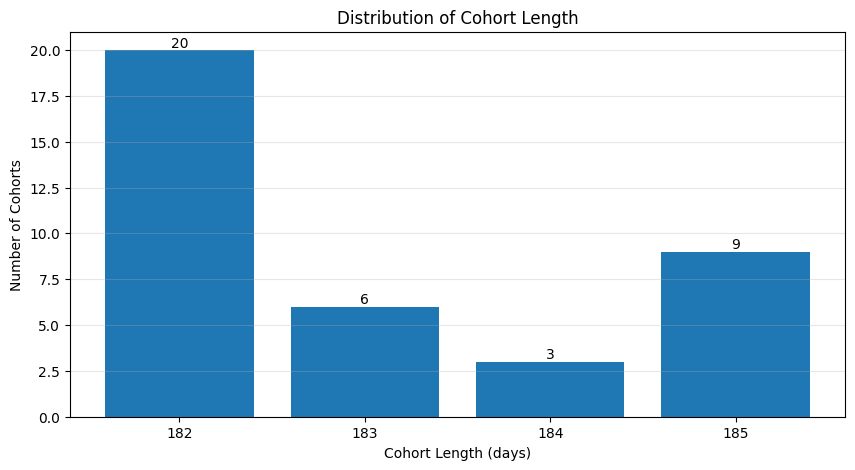

In [86]:
dist = (
    cohort_length['cohort_length']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    dist.index.astype(str),
    dist.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xlabel('Cohort Length (days)')
plt.ylabel('Number of Cohorts')
plt.title('Distribution of Cohort Length')
plt.grid(axis='y', alpha=0.3)

plt.show()

Distribution of running revenue per cohort

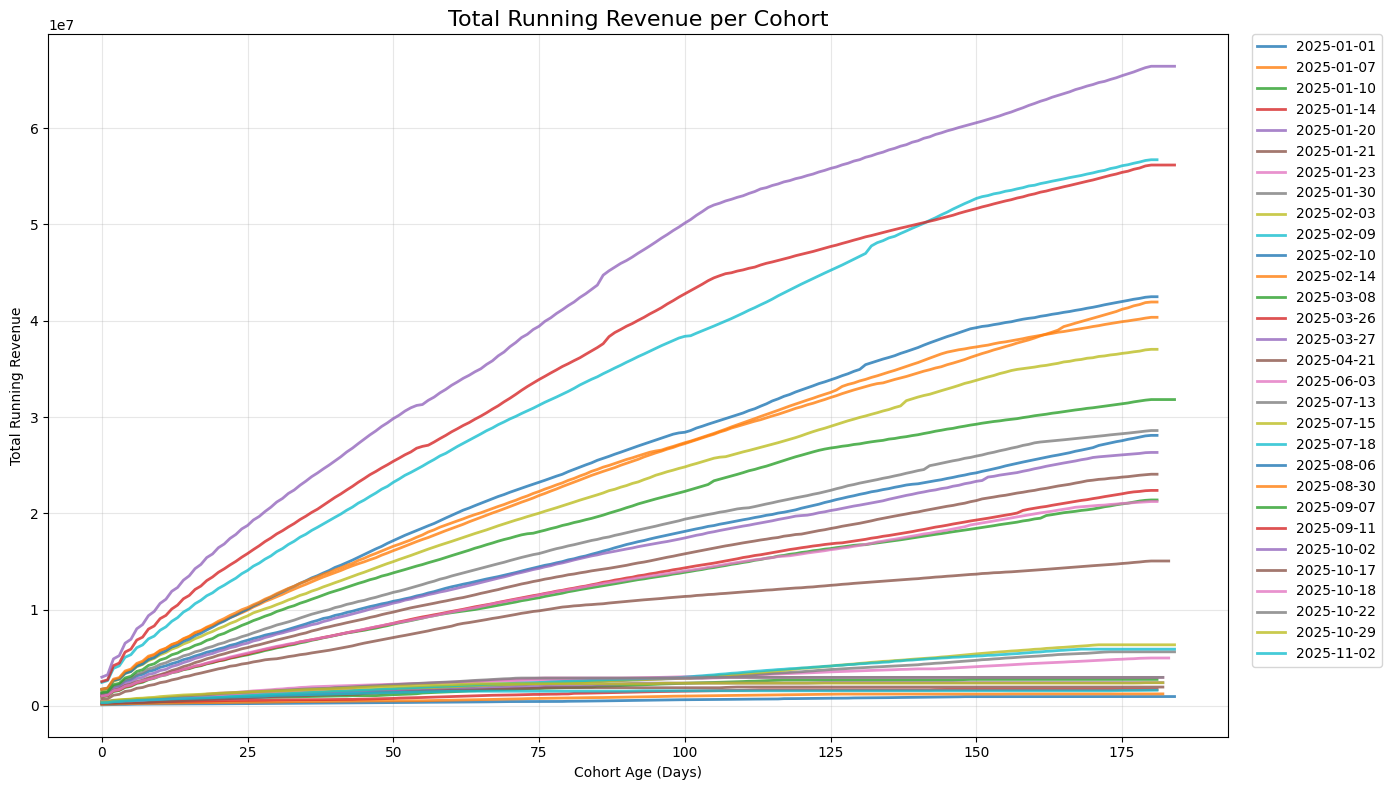

In [87]:
import matplotlib.pyplot as plt

sample = (
    df["date_created_at"]
    .drop_duplicates()
    .sample(min(30, df["date_created_at"].nunique()), random_state=42)
)

plt.figure(figsize=(14, 8))

for cohort in sorted(sample):

    temp = (
        df[df["date_created_at"] == cohort]
        .groupby("cohort_age", as_index=False)["revenue_running_total"]
        .sum()
        .sort_values("cohort_age")
    )

    plt.plot(
        temp["cohort_age"],
        temp["revenue_running_total"],
        linewidth=2,
        alpha=0.8,
        label=cohort.strftime("%Y-%m-%d")
    )

plt.title("Total Running Revenue per Cohort", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Total Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Average revenue daily push distribution per-cohort age per-adnet

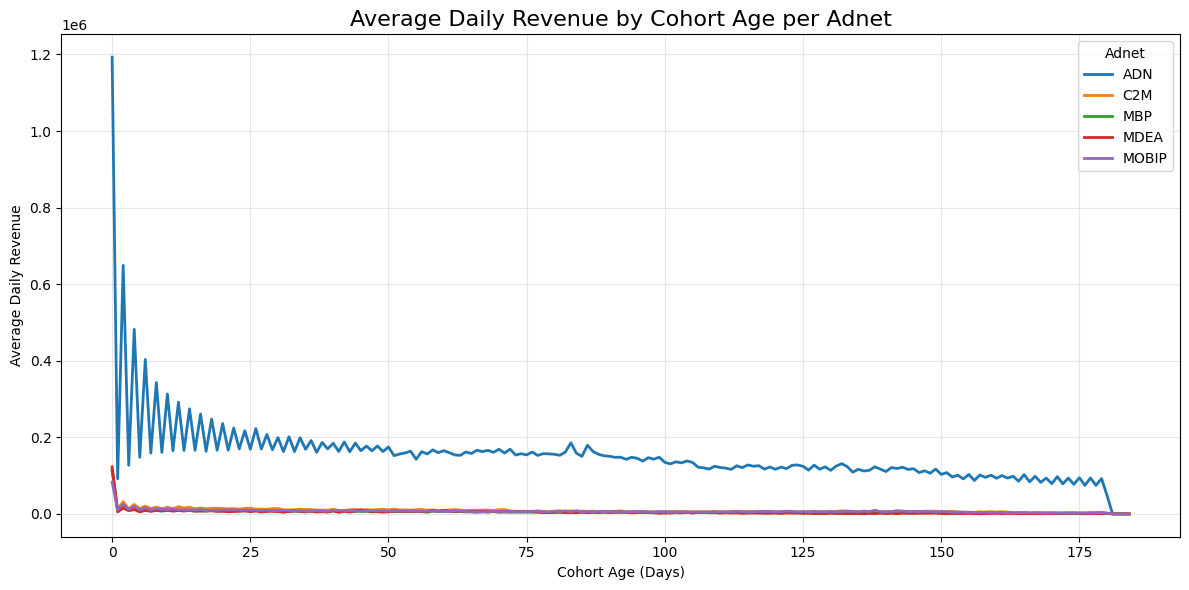

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in (
    df.groupby("adnet")
):

    avg_daily = (
        temp
        .groupby("cohort_age")["revenue_dailypush"]
        .mean()
    )

    plt.plot(
        avg_daily.index,
        avg_daily.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Daily Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Daily Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Average total revenue distribution per cohort age

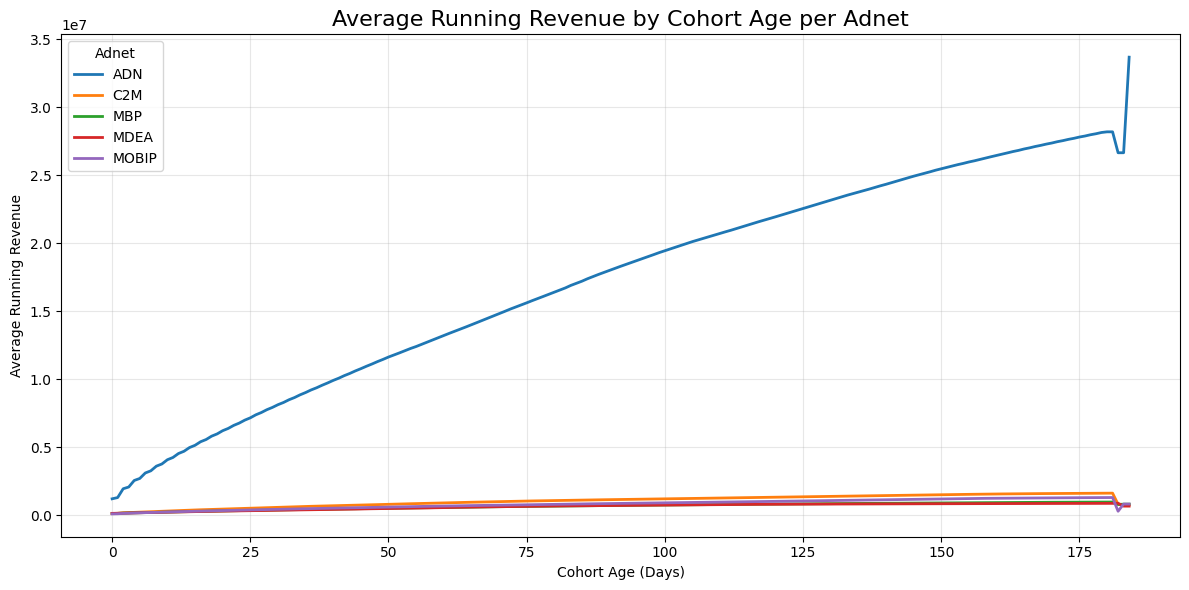

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in df.groupby("adnet"):

    avg_running = (
        temp
        .groupby("cohort_age")["revenue_running_total"]
        .mean()
    )

    plt.plot(
        avg_running.index,
        avg_running.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Running Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Running Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Numerical correlation

<Axes: >

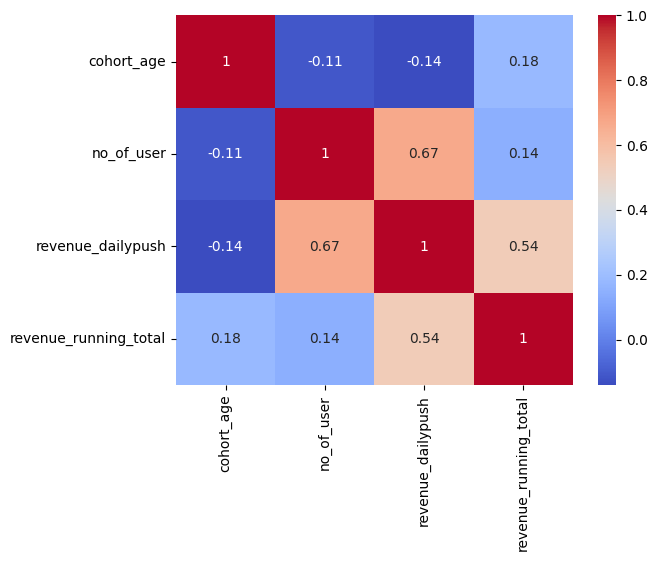

In [90]:
numeric_cols = [
    'cohort_age',
    'no_of_user',
    'revenue_dailypush',
    'revenue_running_total'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

## Preprocessing

### Sort Data

Final preparation with sorting date created and cohort age

In [91]:
df = (
    df
    .sort_values(
        ['date_created_at', 'cohort_age']
    )
    .reset_index(drop=True)
)

In [92]:
df.head()

,cohort_age,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,day_of_week,day_of_month,is_weekend
0,0,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,2,1,0
1,0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,2,1,0
2,0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,2,1,0
3,0,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,2,1,0
4,1,2025-01-01,ADN,2025-01-02,39,78000.0,DAILYPUSH,1132000.0,3,2,0


### Encoding

Create new dataframe for preprocessing process

In [93]:
df_model = df.copy()

subject_encoder = LabelEncoder()
adnet_encoder = LabelEncoder()

Subject encoding

In [94]:
df_model['subject_encoded'] = subject_encoder.fit_transform(df_model['subject'])

In [95]:
df_model.head()

,cohort_age,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,day_of_week,day_of_month,is_weekend,subject_encoded
0,0,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,2,1,0,1
1,0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,2,1,0,1
2,0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,2,1,0,1
3,0,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,2,1,0,1
4,1,2025-01-01,ADN,2025-01-02,39,78000.0,DAILYPUSH,1132000.0,3,2,0,0


Adnet encoding

In [96]:
df_model['adnet_encoded'] = adnet_encoder.fit_transform(df_model['adnet'])

In [97]:
df_model.head()

,cohort_age,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,day_of_week,day_of_month,is_weekend,subject_encoded,adnet_encoded
0,0,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,2,1,0,1,0
1,0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,2,1,0,1,1
2,0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,2,1,0,1,2
3,0,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,2,1,0,1,4
4,1,2025-01-01,ADN,2025-01-02,39,78000.0,DAILYPUSH,1132000.0,3,2,0,0,0


### Feature Selection

Selecting feature for new dataframe

In [98]:
KEEP_COLS = [
    'date_created_at',
    'adnet',
    'cohort_age',
    'revenue_running_total',
    'revenue_dailypush',
    'no_of_user',
    'day_of_week',
    'day_of_month',
    'is_weekend',
    'subject_encoded',
    'adnet_encoded'
]

df_model = df_model[KEEP_COLS]

In [99]:
df_model.head()

,date_created_at,adnet,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,day_of_month,is_weekend,subject_encoded,adnet_encoded
0,2025-01-01,ADN,0,1054000.0,1054000.0,2662,2,1,0,1,0
1,2025-01-01,C2M,0,6000.0,6000.0,86,2,1,0,1,1
2,2025-01-01,MBP,0,136000.0,136000.0,686,2,1,0,1,2
3,2025-01-01,MOBIP,0,68000.0,68000.0,596,2,1,0,1,4
4,2025-01-01,ADN,1,1132000.0,78000.0,39,3,2,0,0,0


### Split Data

Split to train 80% and validation 20% from total cohorts

In [100]:
cohorts = sorted(df_model['date_created_at'].unique())

split_idx = int(len(cohorts) * 0.8)

train_cohorts = cohorts[:split_idx]
val_cohorts = cohorts[split_idx:]

In [101]:
print("Total Train Cohort:", len(train_cohorts))
print("Sample Train Cohort:", train_cohorts)

print("Total Val Cohort:", len(val_cohorts))
print("Sample Val Cohort:", val_cohorts)

Total Train Cohort: 30
Sample Train Cohort: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-07 00:00:00'), Timestamp('2025-01-10 00:00:00'), Timestamp('2025-01-14 00:00:00'), Timestamp('2025-01-20 00:00:00'), Timestamp('2025-01-21 00:00:00'), Timestamp('2025-01-23 00:00:00'), Timestamp('2025-01-28 00:00:00'), Timestamp('2025-01-30 00:00:00'), Timestamp('2025-02-03 00:00:00'), Timestamp('2025-02-08 00:00:00'), Timestamp('2025-02-09 00:00:00'), Timestamp('2025-02-10 00:00:00'), Timestamp('2025-02-14 00:00:00'), Timestamp('2025-02-17 00:00:00'), Timestamp('2025-03-08 00:00:00'), Timestamp('2025-03-26 00:00:00'), Timestamp('2025-03-27 00:00:00'), Timestamp('2025-03-30 00:00:00'), Timestamp('2025-04-21 00:00:00'), Timestamp('2025-05-13 00:00:00'), Timestamp('2025-06-03 00:00:00'), Timestamp('2025-06-24 00:00:00'), Timestamp('2025-07-13 00:00:00'), Timestamp('2025-07-15 00:00:00'), Timestamp('2025-07-18 00:00:00'), Timestamp('2025-08-06 00:00:00'), Timestamp('2025-08-30 00:00:00'), Tim

Insert to pandas for next step (forecasting)

In [102]:
train_df = df_model[df_model['date_created_at'].isin(train_cohorts)]
val_df = df_model[df_model['date_created_at'].isin(val_cohorts)]

In [103]:
print("Total Cohorts Train:", train_df["date_created_at"].nunique())
print("")
print("Total Adnets:", train_df["adnet_encoded"].nunique())
print(train_df["adnet_encoded"].unique())
print("")
print("Total Cohorts per Adnet:", train_df.groupby("adnet_encoded")["date_created_at"].nunique())

Total Cohorts Train: 30

Total Adnets: 5
[0 1 2 4 3]

Total Cohorts per Adnet: adnet_encoded
0    26
1    20
2    25
3     8
4    19
Name: date_created_at, dtype: int64


In [104]:
print("Total Cohorts Val:", val_df["date_created_at"].nunique())
print("")
print("Total Adnets:", val_df["adnet_encoded"].nunique())
print(val_df["adnet_encoded"].unique())
print("")
print("Total Cohorts per Adnet:", val_df.groupby("adnet_encoded")["date_created_at"].nunique())

Total Cohorts Val: 8

Total Adnets: 4
[2 3 4 1]

Total Cohorts per Adnet: adnet_encoded
1    4
2    8
3    8
4    3
Name: date_created_at, dtype: int64


### Target

Setup feature and target for training

In [105]:
# TimesFM 2.0 covariate setup.
# The target enters the model as the autoregressive context (`inputs`),
# NOT as a covariate. Covariates are exogenous extras only and are read
# straight from the engineered columns above.
TARGET = 'revenue_running_total'

# Static covariate (constant per series)
STATIC_CAT = ['adnet']

# Dynamic covariates: deterministic, known across the whole horizon
DYNAMIC_NUM = ['day_of_month']
DYNAMIC_CAT = ['day_of_week', 'is_weekend']

The running total enters the model as the autoregressive context. Extra signal is added by an in-context linear regression (XReg) over the covariates: a static adnet, and known-future day_of_month, day_of_week, is_weekend. cohort_age is intentionally excluded — as a linear regressor it extrapolates the steep early-growth slope and massively overshoots the saturating LTV curve, so the trend is left to TimesFM (which fits the residual). revenue_running_total is never used as a covariate (that would leak the target).

Checking data train

In [106]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17918 entries, 0 to 17917
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        17918 non-null  datetime64[ns]
 1   adnet                  17918 non-null  object        
 2   cohort_age             17918 non-null  int64         
 3   revenue_running_total  17918 non-null  float64       
 4   revenue_dailypush      17918 non-null  float64       
 5   no_of_user             17918 non-null  Int64         
 6   day_of_week            17918 non-null  int32         
 7   day_of_month           17918 non-null  int32         
 8   is_weekend             17918 non-null  int64         
 9   subject_encoded        17918 non-null  int64         
 10  adnet_encoded          17918 non-null  int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), int32(2), int64(4), object(1)
memory usage: 1.5+ MB


In [107]:
train_df.head()

,date_created_at,adnet,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,day_of_month,is_weekend,subject_encoded,adnet_encoded
0,2025-01-01,ADN,0,1054000.0,1054000.0,2662,2,1,0,1,0
1,2025-01-01,C2M,0,6000.0,6000.0,86,2,1,0,1,1
2,2025-01-01,MBP,0,136000.0,136000.0,686,2,1,0,1,2
3,2025-01-01,MOBIP,0,68000.0,68000.0,596,2,1,0,1,4
4,2025-01-01,ADN,1,1132000.0,78000.0,39,3,2,0,0,0


Checking data validation

In [108]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4202 entries, 17918 to 22119
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        4202 non-null   datetime64[ns]
 1   adnet                  4202 non-null   object        
 2   cohort_age             4202 non-null   int64         
 3   revenue_running_total  4202 non-null   float64       
 4   revenue_dailypush      4202 non-null   float64       
 5   no_of_user             4202 non-null   Int64         
 6   day_of_week            4202 non-null   int32         
 7   day_of_month           4202 non-null   int32         
 8   is_weekend             4202 non-null   int64         
 9   subject_encoded        4202 non-null   int64         
 10  adnet_encoded          4202 non-null   int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), int32(2), int64(4), object(1)
memory usage: 365.2+ KB


In [109]:
val_df.head()

,date_created_at,adnet,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,day_of_month,is_weekend,subject_encoded,adnet_encoded
17918,2025-09-11,MBP,0,140000.0,140000.0,1198,3,11,0,1,2
17919,2025-09-11,MDEA,0,162000.0,162000.0,1553,3,11,0,1,3
17920,2025-09-11,MBP,1,148000.0,8000.0,4,4,12,0,0,2
17921,2025-09-11,MDEA,1,168000.0,6000.0,3,4,12,0,0,3
17922,2025-09-11,MBP,2,164000.0,16000.0,8,5,13,1,0,2


## Forecast Setup

### Series Builder

Helpers that read the prepared series and its covariate columns. build_series pulls one (cohort, adnet) from the daily grid; run_forecast fits the XReg linear model on the covariates, lets TimesFM forecast the residual, recombines them, and keeps the cumulative forecast monotone. No feature engineering happens here — covariates come from the columns built earlier.

In [110]:
from timesfm.utils import xreg_lib

CONTEXT_LEN = 2048   # max context length for TimesFM 2.5
HORIZON_LEN = 512    # max forecast horizon per call
CONTEXT_MIN = SEED_DAYS     # minimum history required before forecasting
RIDGE = 1.0          # ridge penalty for the in-context XReg linear fit


def build_series(data, cohort, adnet_val):
    """Pull one (cohort, adnet) series and its covariate columns.

    Assumes data is already on a continuous daily grid (see Feature
    Engineering). Returns the target plus the dynamic covariate arrays.
    """
    g = (
        data[(data["date_created_at"] == cohort) & (data["adnet"] == adnet_val)]
        .sort_values("cohort_age")
    )
    if g.empty:
        return None

    return {
        "cohort": pd.Timestamp(cohort),
        "adnet": str(adnet_val),
        "target": g[TARGET].to_numpy(dtype=float),
        "num": {k: g[k].to_numpy(dtype=float) for k in DYNAMIC_NUM},
        "cat": {k: g[k].astype(int).astype(str).tolist() for k in DYNAMIC_CAT},
        "length": len(g),
    }


def run_forecast(series_list, seed_lens):
    """Forecast a batch of series with covariates via XReg + TimesFM.

    XReg fits a linear model (target ~ covariates) on the context, TimesFM
    forecasts the residual, and the two are recombined. Forecasts are clipped
    so the cumulative running total never drops below the last seed value and
    never decreases.
    """
    targets, train_lens, test_lens = [], [], []
    tr_num = {k: [] for k in DYNAMIC_NUM}
    te_num = {k: [] for k in DYNAMIC_NUM}
    tr_cat = {k: [] for k in DYNAMIC_CAT}
    te_cat = {k: [] for k in DYNAMIC_CAT}
    stat_cat = {k: [] for k in STATIC_CAT}

    for s, seed in zip(series_list, seed_lens):
        n_steps = s["length"] - seed
        targets.append(s["target"][:seed].tolist())
        train_lens.append(seed)
        test_lens.append(n_steps)

        for k in DYNAMIC_NUM:
            tr_num[k].append(s["num"][k][:seed].tolist())
            te_num[k].append(s["num"][k][seed:seed + n_steps].tolist())
        for k in DYNAMIC_CAT:
            tr_cat[k].append(s["cat"][k][:seed])
            te_cat[k].append(s["cat"][k][seed:seed + n_steps])
        for k in STATIC_CAT:
            stat_cat[k].append(s["adnet"])

    xreg = xreg_lib.BatchedInContextXRegLinear(
        targets=targets,
        train_lens=train_lens,
        test_lens=test_lens,
        train_dynamic_numerical_covariates=tr_num,
        train_dynamic_categorical_covariates=tr_cat,
        test_dynamic_numerical_covariates=te_num,
        test_dynamic_categorical_covariates=te_cat,
        static_categorical_covariates=stat_cat,
    )

    fit_out = xreg.fit(ridge=RIDGE, debug_info=True)
    xreg_horizon, xreg_context = fit_out[0], fit_out[1]

    # TimesFM forecasts the residual (target - in-context linear fit)
    residuals = [
        np.asarray(t, dtype=float) - np.asarray(c, dtype=float)
        for t, c in zip(targets, xreg_context)
    ]
    point_forecast, _ = tfm.forecast(horizon=HORIZON_LEN, inputs=residuals)

    preds = []
    for i, (s, seed) in enumerate(zip(series_list, seed_lens)):
        n_steps = s["length"] - seed
        combined = point_forecast[i, :n_steps] + np.asarray(xreg_horizon[i], dtype=float)
        floor = s["target"][seed - 1]
        combined = np.maximum.accumulate(np.clip(combined, floor, None))  # keep monotone
        preds.append(combined)

    return preds

## Modeling

### TimesFM

TimesFM is used zero-shot — no training loop. Load the 2.5 200M PyTorch checkpoint and compile. Covariates are added separately through an in-context linear regression (XReg), so TimesFM itself only forecasts the residual.

In [111]:
import torch
import timesfm

torch.set_float32_matmul_precision("high")

# TimesFM 2.5 - 200M checkpoint (PyTorch). Covariates are handled separately via XReg.
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

tfm.compile(
    timesfm.ForecastConfig(
        max_context=CONTEXT_LEN,
        max_horizon=HORIZON_LEN,
        normalize_inputs=True,
        use_continuous_quantile_head=False,   # point forecast only
        force_flip_invariance=False,
        infer_is_positive=False,              # TimesFM forecasts the XReg residual (can be negative)
        fix_quantile_crossing=True,
    )
)

## Evaluation

### Visualization

Evaluate on the validation cohorts: rebuild each series on a daily grid, use all but the last EVAL_HORIZON days as context, forecast the held-out tail with covariates, then compare against the actuals.

In [112]:
EVAL_HORIZON = SEED_DAYS

eval_series = []
eval_seed_lens = []
eval_actuals = []
evaluated_series = []

for cohort in val_cohorts:

    adnets = (
        val_df.loc[val_df["date_created_at"] == cohort, "adnet"]
        .unique()
    )

    for adnet_val in adnets:

        s = build_series(val_df, cohort, adnet_val)

        if s is None or s["length"] < CONTEXT_MIN + EVAL_HORIZON:
            continue

        seed = s["length"] - EVAL_HORIZON

        eval_series.append(s)
        eval_seed_lens.append(seed)
        eval_actuals.append(s["target"][seed:])
        evaluated_series.append((cohort, adnet_val))

print("Evaluated series:", len(eval_series))

if not eval_series:
    raise ValueError(
        f"No validation series with >= {CONTEXT_MIN + EVAL_HORIZON} days. "
        f"Lower SEED_DAYS / EVAL_HORIZON."
    )

preds = run_forecast(eval_series, eval_seed_lens)

y_pred = np.concatenate([p[:EVAL_HORIZON] for p in preds])
y_val = np.concatenate(eval_actuals)

Evaluated series: 23


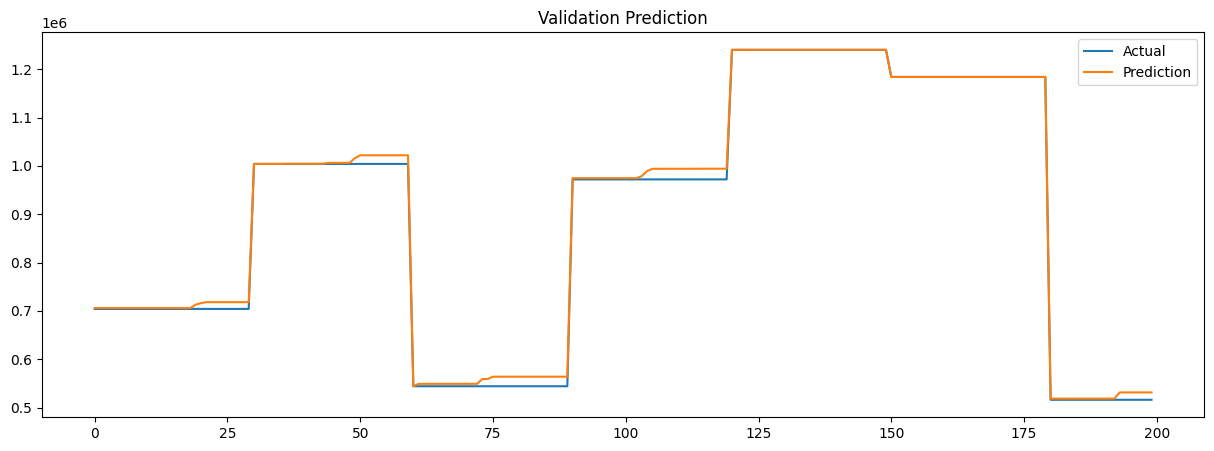

In [113]:
plt.figure(figsize=(15,5))

plt.plot(
    y_val[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Prediction'
)

plt.title('Validation Prediction')

plt.legend()

plt.show()

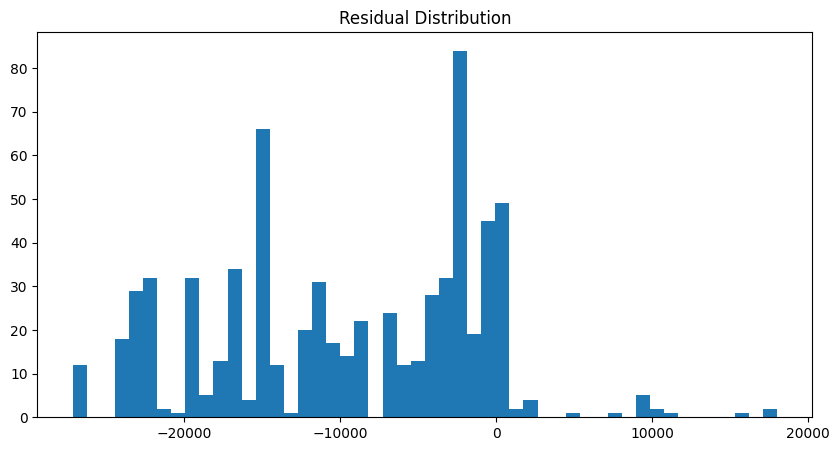

In [114]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual Distribution')

plt.show()

### Metrics

Detail evaluation metrics in MAE, RMSE, MAPE

In [115]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_val,
    y_pred
) * 100

In [116]:
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 10096.479864
RMSE : 12899.752222
MAPE : 14.43%


## Projection

Use the first SEED_DAYS of a cohort as context and let TimesFM forecast all remaining days in a single multi-horizon call (no recursive stepping needed).

Select cohort and run projection

In [117]:
candidates = [
    c for c in val_cohorts
    if int(df[df["date_created_at"] == c]["cohort_age"].max()) >= SEED_DAYS
]

print("Eligible cohorts:", len(candidates))

# Pilih cohort
cohort = candidates[1]

# Lihat adnet yang tersedia pada cohort tersebut
available_adnets = df.loc[df["date_created_at"] == cohort, "adnet"].unique()
print("Available Adnets:", available_adnets)

adnet = available_adnets[0]
# adnet = "MBP"
# adnet = "MDEA"

s = build_series(df, cohort, adnet)

seed_len = SEED_DAYS
n_steps = s["length"] - seed_len

pred_future = run_forecast([s], [seed_len])[0][:n_steps]

context = s["target"][:seed_len]
actual_future = s["target"][seed_len:]

print("Cohort      :", cohort)
print("Adnet       :", adnet)
print("Seed days   :", seed_len)
print("Future days :", n_steps)

print(
    f"Predicted running total at day "
    f"{seed_len + n_steps - 1}: {pred_future[-1]:,.0f}"
)
print(
    f"Actual    running total at day "
    f"{seed_len + n_steps - 1}: {actual_future[-1]:,.0f}"
)

Eligible cohorts: 8
Available Adnets: ['MBP' 'MDEA']
Cohort      : 2025-09-17 00:00:00
Adnet       : MBP
Seed days   : 30
Future days : 152
Predicted running total at day 181: 216,500
Actual    running total at day 181: 544,000


Actual vs projection visualization

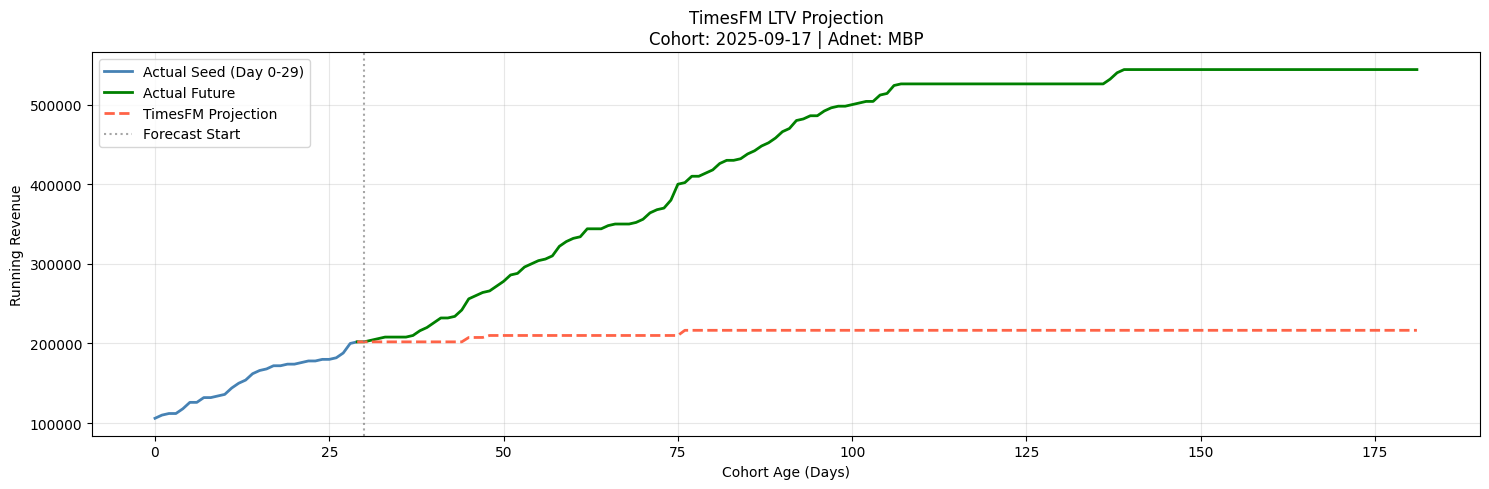

In [118]:
seed_age = np.arange(seed_len)
future_age = np.arange(seed_len, seed_len + n_steps)

# sambungkan seed -> future / projection di titik batas seed
fut_x = np.concatenate([[seed_age[-1]], future_age])
fut_y = np.concatenate([[context[-1]], actual_future])
pred_y = np.concatenate([[context[-1]], pred_future])

plt.figure(figsize=(15, 5))

plt.plot(
    seed_age,
    context,
    label=f"Actual Seed (Day 0-{seed_len-1})",
    color="steelblue",
    linewidth=2
)

plt.plot(
    fut_x,
    fut_y,
    label="Actual Future",
    color="green",
    linewidth=2
)

plt.plot(
    fut_x,
    pred_y,
    label="TimesFM Projection",
    color="tomato",
    linestyle="--",
    linewidth=2
)

plt.axvline(
    x=seed_len,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label="Forecast Start"
)

plt.title(
    f"TimesFM LTV Projection\n"
    f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
)

plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Testing on Unseen Data

This section evaluates TimesFM on a completely hold-out dataset (linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts) containing 5 unseen cohorts that the model has never been exposed to.

Because TimesFM is a **univariate, zero-shot** foundation model, the unseen data needs only minimal preparation: load the raw table, derive cohort_age (used to order the series and slice seed/horizon), and sort. No scaler or encoder is fit, no scaling is applied, and day_of_week / encodings are not needed — the model consumes the raw revenue_running_total series directly.

### Loader

Query the unseen testing table from Google BigQuery

In [119]:
# df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')
# df_unseen.head()

df_unseen = unseen_raw.copy()

### Feature Engineering

Derive cohort_age and sort. The daily-grid rebuild and covariate construction are applied later inside build_series / run_forecast, identical to the development pipeline.

In [120]:
df_unseen['date_created_at'] = pd.to_datetime(df_unseen['date_created_at'])
df_unseen['date_update']     = pd.to_datetime(df_unseen['date_update'])

df_unseen['cohort_age'] = (
    df_unseen['date_update'] - df_unseen['date_created_at']
).dt.days

# Same continuous daily grid + calendar features as the development pipeline
df_unseen = to_daily_grid(df_unseen)
df_unseen['day_of_week'] = df_unseen['date_update'].dt.dayofweek
df_unseen['day_of_month'] = df_unseen['date_update'].dt.day
df_unseen['is_weekend'] = (df_unseen['date_update'].dt.dayofweek >= 5).astype(int)

df_unseen = (
    df_unseen
    .sort_values(['date_created_at', 'cohort_age'])
    .reset_index(drop=True)
)

df_unseen.head()

,cohort_age,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,day_of_week,day_of_month,is_weekend
0,0,2025-11-05,MBP,2025-11-05,975,156000.0,FIRSTPUSH,156000.0,2,5,0
1,0,2025-11-05,MDEA,2025-11-05,955,142000.0,FIRSTPUSH,142000.0,2,5,0
2,1,2025-11-05,MBP,2025-11-06,5,10000.0,DAILYPUSH,166000.0,3,6,0
3,1,2025-11-05,MDEA,2025-11-06,6,12000.0,DAILYPUSH,154000.0,3,6,0
4,2,2025-11-05,MBP,2025-11-07,9,18000.0,DAILYPUSH,184000.0,4,7,0


Checking unseen cohorts and their length

In [121]:
unseen_cohorts = sorted(df_unseen["date_created_at"].unique())

print("Total unseen cohorts:", len(unseen_cohorts))

for cohort in unseen_cohorts:

    print(f"\nCohort: {str(cohort)[:10]}")

    temp = (
        df_unseen[
            df_unseen["date_created_at"] == cohort
        ]
        .groupby("adnet")["cohort_age"]
        .max()
        .sort_index()
    )

    for adnet, max_age in temp.items():
        print(f"  {adnet:<6} -> {int(max_age)+1} days")

Total unseen cohorts: 4

Cohort: 2025-11-05
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-11-20
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-11-29
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-12-05
  MBP    -> 183 days
  MDEA   -> 183 days


### Visualization

Distribution of running revenue per cohort

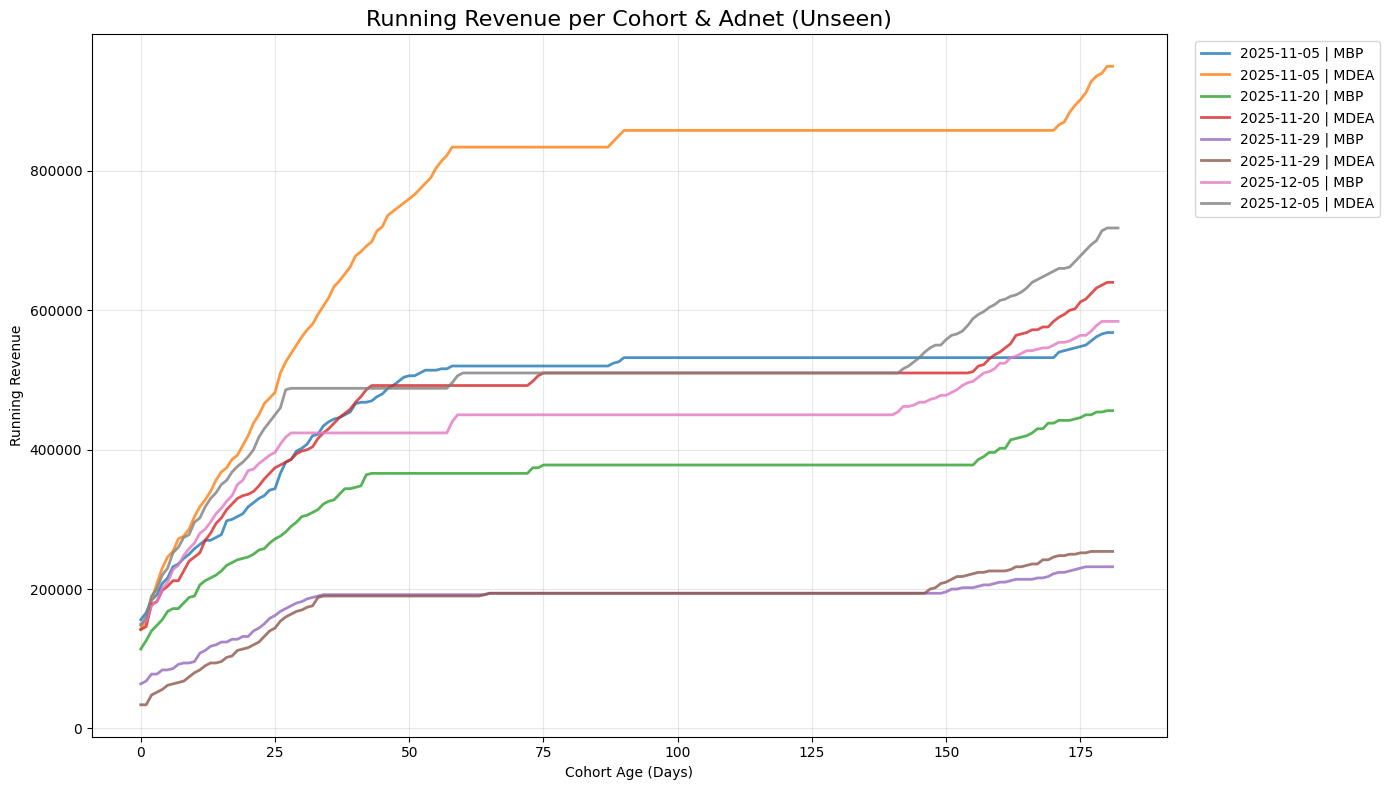

In [122]:
plt.figure(figsize=(14, 8))

for (cohort, adnet), temp in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    temp = temp.sort_values("cohort_age")

    plt.plot(
        temp["cohort_age"],
        temp["revenue_running_total"],
        linewidth=2,
        alpha=0.8,
        label=f"{pd.Timestamp(cohort).strftime('%Y-%m-%d')} | {adnet}"
    )

plt.title("Running Revenue per Cohort & Adnet (Unseen)", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")

plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Forecast

For each unseen (cohort, adnet), rebuild on a daily grid, seed the first SEED_DAYS days, and forecast the remaining horizon with covariates in a single call. Shorter cohorts reduce the seed so at least one day is forecast.

In [123]:
def forecast_one(s, seed_len):
    """Project one prepared series.

    Returns:
        context, actual_future, pred_future, n_steps
    """
    seed_len = min(seed_len, s["length"] - 1)
    n_steps = s["length"] - seed_len

    pred_future = run_forecast([s], [seed_len])[0][:n_steps]

    context = s["target"][:seed_len]
    actual_future = s["target"][seed_len:]

    return context, actual_future, pred_future, n_steps

In [124]:
results = {}

for cohort in sorted(df_unseen["date_created_at"].unique()):

    for adnet in df_unseen.loc[df_unseen["date_created_at"] == cohort, "adnet"].unique():

        s = build_series(df_unseen, cohort, adnet)

        if s is None or s["length"] < 2:
            continue

        seed_len = min(SEED_DAYS, s["length"] - 1)

        context, actual_future, pred_future, n_steps = forecast_one(s, seed_len)

        results[(pd.Timestamp(cohort), adnet)] = {
            "adnet": adnet,
            "seed_len": seed_len,
            "context": context,
            "actual_future": actual_future,
            "pred_future": pred_future,
            "n_steps": n_steps,
        }

        mape_full = mean_absolute_percentage_error(actual_future, pred_future) * 100

        print(
            f"{str(cohort)[:10]} | {adnet:<6} "
            f"seed={seed_len:>2}d forecast={n_steps:>3}d "
            f"| final pred={pred_future[-1]:>12,.0f} "
            f"actual={actual_future[-1]:>12,.0f} "
            f"MAPE={mape_full:.2f}%"
        )

2025-11-05 | MBP    seed=30d forecast=152d | final pred=     483,505 actual=     568,000 MAPE=8.82%
2025-11-05 | MDEA   seed=30d forecast=152d | final pred=     754,626 actual=     950,000 MAPE=12.08%
2025-11-20 | MBP    seed=30d forecast=152d | final pred=     488,854 actual=     456,000 MAPE=26.12%
2025-11-20 | MDEA   seed=30d forecast=152d | final pred=     969,000 actual=     640,000 MAPE=80.53%
2025-11-29 | MBP    seed=30d forecast=152d | final pred=     195,540 actual=     232,000 MAPE=2.83%
2025-11-29 | MDEA   seed=30d forecast=152d | final pred=     188,503 actual=     254,000 MAPE=6.12%
2025-12-05 | MBP    seed=30d forecast=153d | final pred=     538,081 actual=     584,000 MAPE=14.56%
2025-12-05 | MDEA   seed=30d forecast=153d | final pred=     565,554 actual=     718,000 MAPE=9.42%


Actual vs projection visualization for each unseen cohort

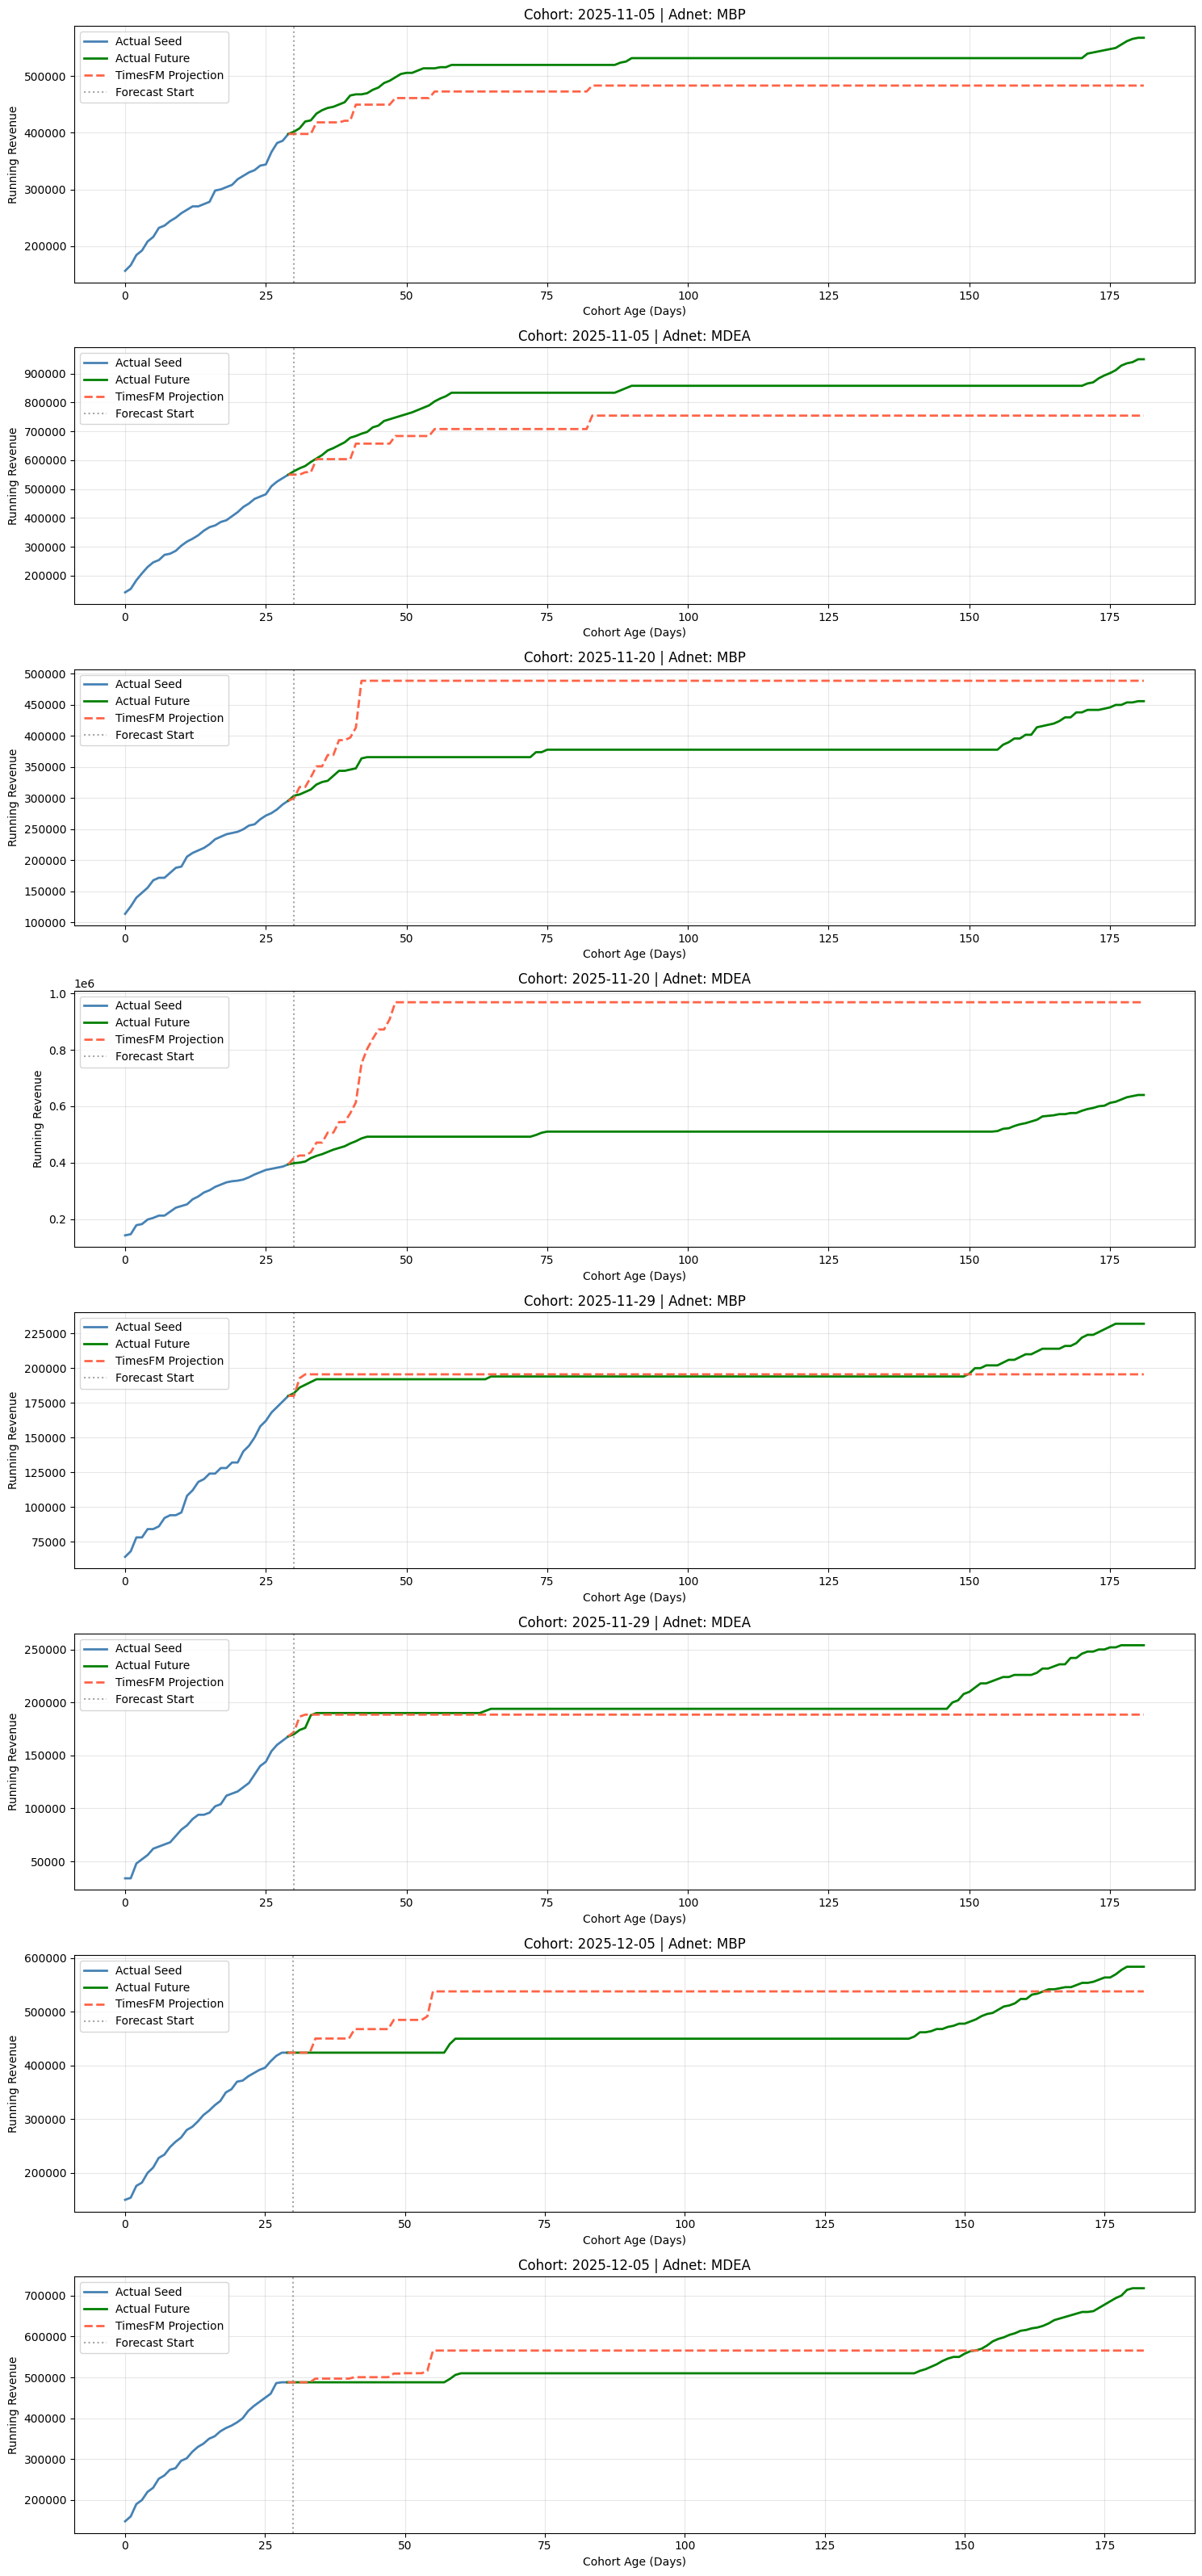

In [125]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(np.atleast_1d(axes), results.items()):

    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_age = np.arange(seed_len)
    future_age = np.arange(seed_len, seed_len + n_steps)

    # sambungkan di titik batas seed
    fut_x = np.concatenate([[seed_age[-1]], future_age])
    fut_y = np.concatenate([[r["context"][-1]], r["actual_future"]])
    pred_y = np.concatenate([[r["context"][-1]], r["pred_future"]])

    ax.plot(seed_age, r["context"], label="Actual Seed", color="steelblue", linewidth=2)
    ax.plot(fut_x, fut_y, label="Actual Future", color="green", linewidth=2)
    ax.plot(fut_x, pred_y, label="TimesFM Projection", color="tomato", linestyle="--", linewidth=2)

    ax.axvline(x=seed_len, color="gray", linestyle=":", alpha=0.7, label="Forecast Start")

    ax.set_title(f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}")
    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()